# Comparison in NATRE region

Goal here is to compare my results in the NATRE region to Ferrari & Polzin results AND to Castro & Brullon results. I want to make a figure analagous to Broullon et al (2026) Fig 2. Start by just making your version in this notebook, then maybe download their data to put everything on one set of axes afterward.

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.path import Path
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cmocean.cm as cmo
import cartopy.crs as ccrs
import gsw
import rioxarray as rxr #load .tif files
import mixsea as mx
import io
import contextlib
import neutral_density as nd

In [2]:
ds_pbar = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_var.nc')

In [3]:
ds_pbar_grid = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_grid_var.nc')
ds_pbar_grad = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_grad_cip_masking.nc')

In [4]:
ds_pbar_grid = ds_pbar_grid.assign_coords(LON_left = ds_pbar_grad.LON_left,LAT_left = ds_pbar_grad.LAT_left)
ds_pbar_grid = xr.merge([ds_pbar_grid, ds_pbar_grad.drop_vars({'DENSITY'})])

In [5]:
K_rho_p = xr.open_dataarray('/swot/SUM05/amf2288/K_rho_filt_p.nc').drop_vars('Z').rename({'PRESSURE':'PRESSURE_mean'})
K_rho_p = K_rho_p.bfill(dim='PRESSURE_mean').ffill(dim='PRESSURE_mean')

## Data Selection

In [6]:
region_mask = (
    (ds_pbar.LAT >= 20) & (ds_pbar.LAT <= 31) &
    (ds_pbar.LON >= -38) & (ds_pbar.LON <= -20) &
    (ds_pbar.TIME >= np.datetime64('2014-01-01')) &
    (ds_pbar.TIME <  np.datetime64('2025-01-01'))
)

NATRE_pbar = ds_pbar.where(region_mask, drop=True)

In [7]:
NATRE_pbar

<xarray.Dataset>
Dimensions:        (PROFILE: 8886, PRESSURE_mean: 1001)
Coordinates:
  * PRESSURE_mean  (PRESSURE_mean) int64 0 2 4 6 8 ... 1992 1994 1996 1998 2000
  * PROFILE        (PROFILE) int64 110380 111287 2256939 ... 1638157 1646617
    LAT            (PROFILE) float64 20.0 20.0 20.0 20.0 ... 30.99 31.0 31.0
    LON            (PROFILE) float64 -25.28 -26.68 -37.02 ... -28.91 -28.91
    TIME           (PROFILE) datetime64[ns] 2015-06-05T19:13:00.000000256 ......
Data variables: (12/16)
    CT_sort        (PROFILE, PRESSURE_mean) float64 nan nan nan ... nan nan nan
    SA_sort        (PROFILE, PRESSURE_mean) float64 nan nan nan ... nan nan nan
    SPICE_sort     (PROFILE, PRESSURE_mean) float64 nan nan nan ... nan nan nan
    DENSITY        (PROFILE, PRESSURE_mean) float64 nan 24.83 24.85 ... nan nan
    CT_sort_m      (PROFILE, PRESSURE_mean) float64 nan nan nan ... nan nan nan
    SA_sort_m      (PROFILE, PRESSURE_mean) float64 nan nan nan ... nan nan nan
    ...             ...
    CT_e_var       (PROFILE, PRESSURE_mean) float64 nan nan nan ... nan nan nan
    SA_e_var       (PROFILE, PRESSURE_mean) float64 nan nan nan ... nan nan nan
    SPICE_e_var    (PROFILE, PRESSURE_mean) float64 nan nan nan ... nan nan nan
    CT_m_var       (PROFILE, PRESSURE_mean) float64 nan nan nan ... nan nan nan
    SA_m_var       (PROFILE, PRESSURE_mean) float64 nan nan nan ... nan nan nan
    SPICE_m_var    (PROFILE, PRESSURE_mean) float64 nan nan nan ... nan nan nan

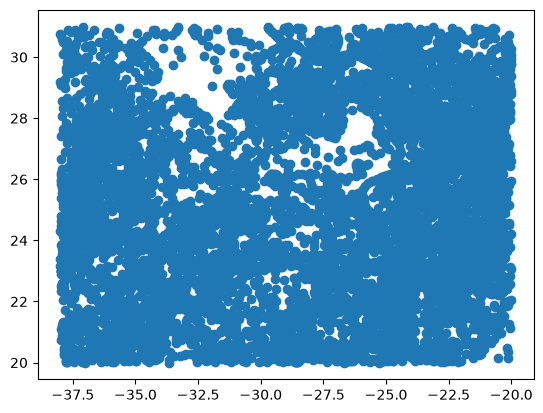

In [8]:
plt.scatter(NATRE_pbar.LON, NATRE_pbar.LAT)

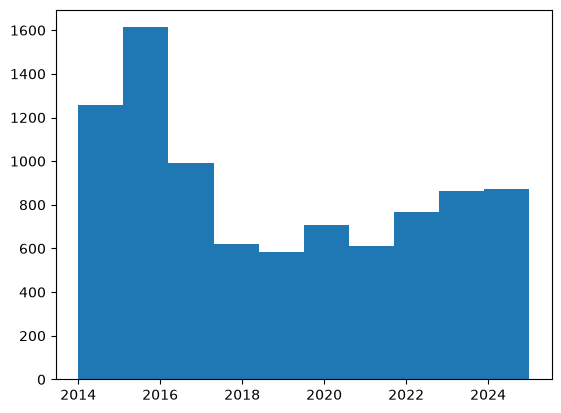

In [9]:
plt.hist(NATRE_pbar.TIME, bins=10);

In [10]:
NATRE_K_rho = K_rho_p.sel(
    LAT=slice(20, 31),
    LON=slice(-38, -20)
)

Text(0.5, 1.0, 'Grid points in NATRE region')

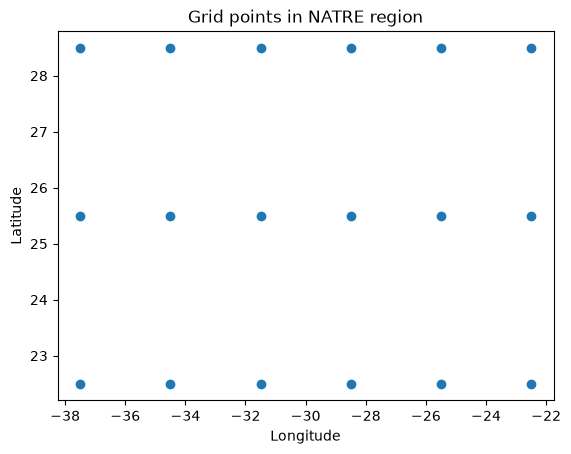

In [11]:
lon2d, lat2d = np.meshgrid(NATRE_K_rho.LON, NATRE_K_rho.LAT)

plt.scatter(lon2d, lat2d)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Grid points in NATRE region")

## [FB Method] Calculate mean profiles

In [12]:
K_mean = NATRE_K_rho.mean(['LON','LAT'])

P_perp_CT = K_mean * NATRE_pbar.CT_m_var.mean('PROFILE')
P_para_CT = K_mean * NATRE_pbar.CT_e_var.mean('PROFILE')

P_perp_SA = K_mean * NATRE_pbar.SA_m_var.mean('PROFILE')
P_para_SA = K_mean * NATRE_pbar.SA_e_var.mean('PROFILE')

In [13]:
FP_K_rho = pd.read_csv('CB_Fig2/FP_K_rho.csv', header=None)
CB_K_rho = pd.read_csv('CB_Fig2/CB_K_rho.csv', header=None)
FP_P_perp_CT = pd.read_csv('CB_Fig2/FP_P_perp_CT.csv', header=None)
FP_P_para_CT = pd.read_csv('CB_Fig2/FP_P_para_CT.csv', header=None)
CB_P_perp_CT = pd.read_csv('CB_Fig2/CB_P_perp_CT.csv', header=None)
CB_P_para_CT = pd.read_csv('CB_Fig2/CB_P_para_CT.csv', header=None)
FP_P_perp_SA = pd.read_csv('CB_Fig2/FP_P_perp_SA.csv', header=None)
FP_P_para_SA = pd.read_csv('CB_Fig2/FP_P_para_SA.csv', header=None)
CB_P_perp_SA = pd.read_csv('CB_Fig2/CB_P_perp_SA.csv', header=None)
CB_P_para_SA = pd.read_csv('CB_Fig2/CB_P_para_SA.csv', header=None)

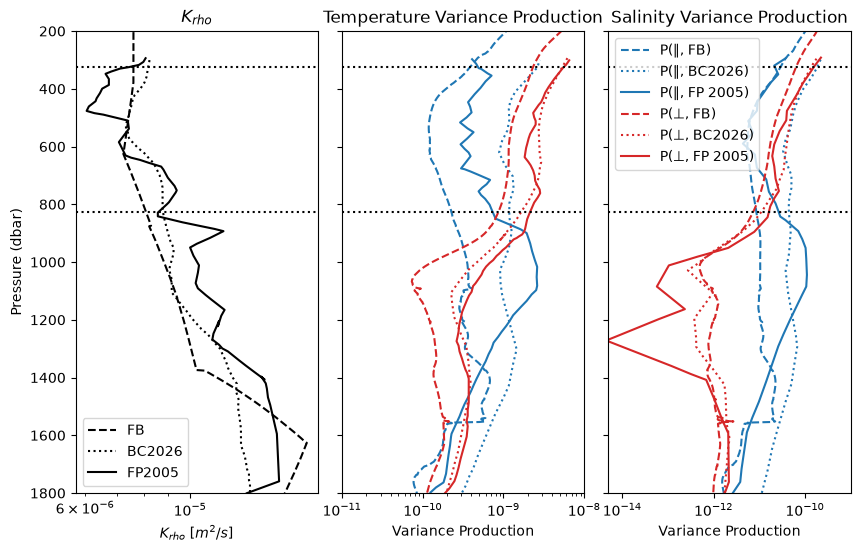

In [14]:
plt.figure(figsize=(10,6))

plt.subplot(131)
K_mean.plot(y='PRESSURE_mean', color='k', linestyle='--', label='FB')
plt.plot(CB_K_rho[0], CB_K_rho[1], color='k', linestyle=':', label='BC2026')
plt.plot(FP_K_rho[0], FP_K_rho[1], color='k', label='FP2005')
plt.axhline(325, color='k', linestyle=':')
plt.axhline(825, color='k', linestyle=':')
plt.legend()
plt.ylabel('Pressure (dbar)')
plt.ylim(1800,200)
plt.xscale('log')
plt.xlabel('$K_{rho}$ [$m^2/s$]')
plt.title('$K_{rho}$')

plt.subplot(132)
P_para_CT.plot(y='PRESSURE_mean', color='tab:blue', linestyle='--', label='P(∥, FB)')
plt.plot(CB_P_para_CT[0], CB_P_para_CT[1], color='tab:blue', linestyle=':', label='P(∥, BC2026)')
plt.plot(FP_P_para_CT[0], FP_P_para_CT[1], color='tab:blue', label='P(∥, FP2005)')
P_perp_CT.plot(y='PRESSURE_mean', color='tab:red', linestyle='--', label='P(⊥, FB)')
plt.plot(CB_P_perp_CT[0], CB_P_perp_CT[1], color='tab:red', linestyle=':', label='P(⊥, BC2026)')
plt.plot(FP_P_perp_CT[0], FP_P_perp_CT[1], color='tab:red', label='P(⊥, FP 2005)')
plt.axhline(325, color='k', linestyle=':')
plt.axhline(825, color='k', linestyle=':')
#plt.legend()
plt.ylabel('')
plt.gca().set_yticklabels([])
plt.ylim(1800,200)
plt.xscale('log')
plt.xlim(1e-11, 1e-8)
plt.xlabel('Variance Production')
plt.title('Temperature Variance Production')

plt.subplot(133)
P_para_SA.plot(y='PRESSURE_mean', color='tab:blue', linestyle='--', label='P(∥, FB)')
plt.plot(CB_P_para_SA[0], CB_P_para_SA[1], color='tab:blue', linestyle=':', label='P(∥, BC2026)')
plt.plot(FP_P_para_SA[0], FP_P_para_SA[1], color='tab:blue', label='P(∥, FP 2005)')
P_perp_SA.plot(y='PRESSURE_mean', color='tab:red', linestyle='--', label='P(⊥, FB)')
plt.plot(CB_P_perp_SA[0], CB_P_perp_SA[1], color='tab:red', linestyle=':', label='P(⊥, BC2026)')
plt.plot(FP_P_perp_SA[0], FP_P_perp_SA[1], color='tab:red', label='P(⊥, FP 2005)')
plt.axhline(325, color='k', linestyle=':')
plt.axhline(825, color='k', linestyle=':')
plt.legend()
plt.ylabel('')
plt.gca().set_yticklabels([])
plt.ylim(1800,200)
plt.xscale('log')
plt.xlim(5e-15, 1e-9)
plt.xlabel('Variance Production')
plt.title('Salinity Variance Production')

plt.subplots_adjust(wspace=0.1)

## BC2026 Method: Compute eps per profile

In [15]:
ds_p = xr.open_dataset('/swot/SUM05/amf2288/ds_p_copilot.nc')

In [16]:
NATRE_p = ds_p.where(region_mask, drop=True)

In [24]:
ds = NATRE_p

def gamma_profile(s, t, p, lon, lat):
    lon_360 = (float(lon) + 360.0) % 360.0
    lat = float(lat)

    s = np.asarray(s, dtype=float)
    t = np.asarray(t, dtype=float)
    p = np.asarray(p, dtype=float)

    gamma = np.full(s.shape, np.nan, dtype=float)

    good = np.isfinite(s) & np.isfinite(t) & np.isfinite(p)
    if good.sum() == 0:
        return gamma

    f = io.StringIO()
    with contextlib.redirect_stdout(f):
        g, dg_lo, dg_hi = nd.gamma_n(
            s=s[good],
            t=t[good],
            p=p[good],
            along=lon_360,
            alat=lat,
        )

    g = np.asarray(g, dtype=float)
    g[g == -99.0] = np.nan
    gamma[good] = g
    return gamma

gamma_n = xr.apply_ufunc(
    gamma_profile,
    ds["PSAL"],
    ds["TEMP"],
    ds["PRESSURE"],
    ds["LON"],
    ds["LAT"],
    input_core_dims=[["PRESSURE"], ["PRESSURE"], ["PRESSURE"], [], []],
    output_core_dims=[["PRESSURE"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
)

NATRE_p = NATRE_p.assign(
    gamma_n=gamma_n.assign_attrs({
        "long_name": "Neutral density",
        "units": "kg m-3",
        "note": "Computed with neutral_density.gamma_n; longitude converted to 0-360; -99 sentinel masked to NaN"
    })
)

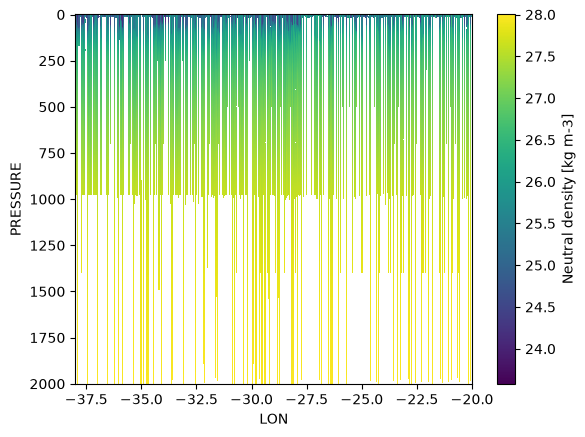

In [18]:
NATRE_p.gamma_n.sortby('LON').plot(x='LON',y='PRESSURE')
plt.gca().invert_yaxis()

In [38]:
g = 9.81
rho0 = 1027.0

ds = NATRE_p

gamma = ds["gamma_n"]   # (PROFILE, PRESSURE)
p = ds["PRESSURE"]      # (PRESSURE), dbar

# Finite differences along pressure index
# N2 is first computed on pressure midpoints, then mapped back to native PRESSURE.
dgamma = gamma.diff("PRESSURE")            # (PROFILE, PRESSURE-1)
dp = p.diff("PRESSURE")                    # (PRESSURE-1), dbar
dp_pa = dp * 1e4                            # Pa

# Convert pressure spacing to geometric spacing (z positive downward)
dz = dp_pa / (rho0 * g)                     # m

# With z positive downward: N2 = +(g/rho0) * d(rho)/dz
N2_mid_vals = (g / rho0) * (dgamma / dz)    # (PROFILE, PRESSURE-1)

# Midpoint pressure coordinate
p_mid = 0.5 * (p.values[:-1] + p.values[1:])

N2_mid = xr.DataArray(
    N2_mid_vals.values,
    dims=("PROFILE", "PRESSURE_mid"),
    coords={
        "PROFILE": ds["PROFILE"],
        "PRESSURE_mid": p_mid,
    },
    name="N2_mid",
    attrs={
        "long_name": "Buoyancy frequency squared from gamma_n gradient (midpoint grid)",
        "units": "s^-2",
        "method": "N2 = (g/rho0) * d(gamma_n)/dz, z positive downward; centered at pressure midpoints",
        "rho0": rho0,
    },
)

# Put N2 back on native PRESSURE grid for compatibility with NATRE_p variables.
# Edge levels (outside midpoint range) remain NaN unless extrapolation is requested.
N2_native = N2_mid.interp(PRESSURE_mid=p).drop_vars("PRESSURE_mid", errors="ignore")
N2_native.name = "N2"
N2_native.attrs = {
    "long_name": "Buoyancy frequency squared from gamma_n gradient",
    "units": "s^-2",
    "method": "Computed on pressure midpoints then linearly interpolated to native PRESSURE grid",
    "rho0": rho0,
}

NATRE_p = NATRE_p.assign(N2_mid=N2_mid, N2=N2_native)

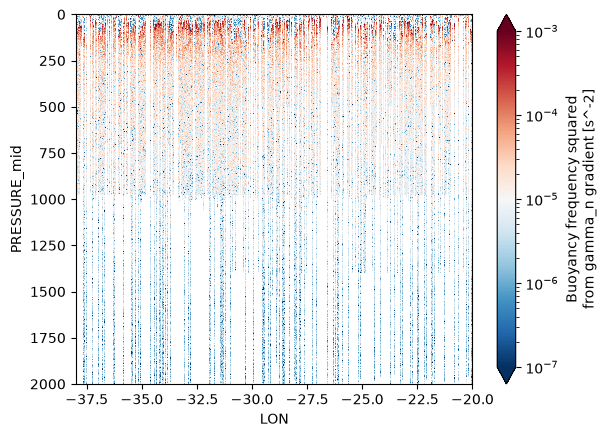

In [ ]:
NATRE_p.N2.sortby('LON').plot(x='LON', y='PRESSURE', norm=colors.LogNorm(vmin=1e-7, vmax=1e-3))
plt.gca().invert_yaxis()

In [40]:
##mixing
# Center points of depth windows. Windows are half overlapping, i.e.
# their size (200m) is double the spacing here (100m).
window_size = 200
min_size = 10.
dZ = window_size // 4
#print("window size {} m, window spacing {} m".format(window_size, dz))
depth_bin = np.arange(dZ, 2000, dZ)
N_PROF = NATRE_p.dims['PROFILE']
# Wavenumber vector. Starts at wavenumber corresponding to a 200m
# wavelength.
m = np.arange(2 * np.pi / window_size, 2 * np.pi / min_size, 2 * np.pi / window_size)
# Wavenumber indices for integration. Shear is integrated from 300m to
# 100m scales. Strain is integrated from 150m to 30m.
m_include_sh = list(range(3))
m_include_st = list(range(1, 12))

/home/amf2288/miniconda3/envs/Argo_Feb_25/lib/python3.11/site-packages/xarray/core/utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(


In [41]:
TEMP = NATRE_p.TEMP.values.T
PSAL = NATRE_p.PSAL.values.T
Z = NATRE_p.PRESSURE.values
Lon = NATRE_p.LON.values
Lat = NATRE_p.LAT.values
N2 = NATRE_p.N2.values.T

In [42]:
eps_st   = np.full((depth_bin.size, N_PROF), np.nan)
Krho_st  = np.full((depth_bin.size, N_PROF), np.nan)
depth_st = np.full((depth_bin.size, N_PROF), np.nan)

for i in range(N_PROF):
    #print(i)
    if np.sum(np.isfinite(TEMP[:,i]+PSAL[:,i]))<100:
        continue
    try:
        eps_shst, krho_shst, diag = mx.shearstrain.nan_shearstrain(
            Z,
            TEMP[:,i],
            PSAL[:,i],
            Lon[i],
            Lat[i],
            TEMP[:,i]*0.,
            TEMP[:,i]*0.,
            Z,
            m=m,
            depth_bin=depth_bin,
            window_size=window_size,
            m_include_sh=m_include_sh,
            m_include_st=m_include_st,
            ladcp_is_shear=True,
            smooth="AL",
            return_diagnostics=True,
        )

    except ValueError as e:
        print(f"Skipped profile at index {i} due to error: {e}")
        continue

    z0 = diag['depth_bin']
    for j in range(z0.size):
        jj = np.where(depth_bin == z0[j])[0]
        if jj.size == 0:
            continue
        eps_st[jj[0],i] = diag['eps_st'][j]
        Krho_st[jj[0],i] = diag['krho_st'][j]

/home/amf2288/miniconda3/envs/Argo_Feb_25/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/amf2288/miniconda3/envs/Argo_Feb_25/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Skipped profile at index 22 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile at index 32 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile at index 38 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile at index 45 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile at index 74 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile at index 188 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile at index 335 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile at index 422 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile at index 570 due to error: zero-size array to reduction operation maximum which has no identi

In [43]:
NATRE_Krho = xr.Dataset(
    data_vars=dict(
        eps_st   = (("PRESSURE", "PROFILE"), eps_st),
        Krho_st  = (("PRESSURE", "PROFILE"), Krho_st),
        depth_st = (("PRESSURE", "PROFILE"), depth_st),
    ),
    coords=dict(
        PRESSURE = depth_bin,
        PROFILE  = NATRE_p.PROFILE.values,
        LAT      = ("PROFILE", NATRE_p.LAT.values),
        LON      = ("PROFILE", NATRE_p.LON.values),
        TIME     = ("PROFILE", NATRE_p.TIME.values),
    ),
    attrs=dict(
        description="Shear/strain-derived dissipation and diffusivity",
        source="mx.shearstrain.nan_shearstrain",
    )
)

In [44]:
gamma = 0.2

# Interpolate native-grid N2 onto Krho pressure bins, then align dims
N2i = NATRE_p.N2.interp(PRESSURE=NATRE_Krho.PRESSURE)
N2i = N2i.transpose("PRESSURE", "PROFILE")

mask = (N2i > 0) & np.isfinite(NATRE_Krho.eps_st)

NATRE_Krho['Krho_OC'] = xr.where(
    mask,
    gamma * NATRE_Krho.eps_st / N2i,
    np.nan
)

Text(0.5, 1.0, '$K_{rho}$')

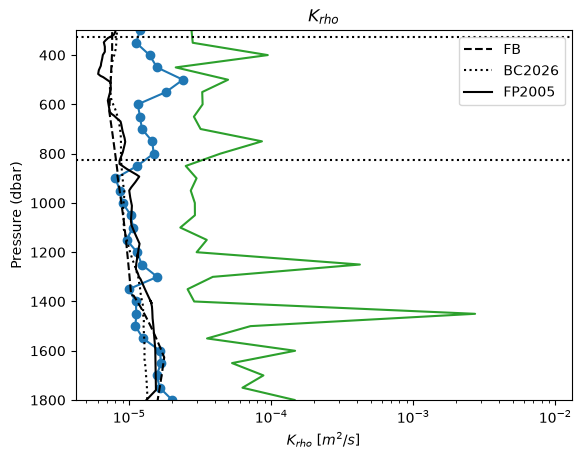

In [45]:
NATRE_Krho.Krho_st.mean('PROFILE').plot(y='PRESSURE', marker='o')
NATRE_Krho.Krho_OC.mean('PROFILE').plot(y='PRESSURE', color='tab:green')
K_mean.plot(y='PRESSURE_mean', color='k', linestyle='--', label='FB')
plt.plot(CB_K_rho[0], CB_K_rho[1], color='k', linestyle=':', label='BC2026')
plt.plot(FP_K_rho[0], FP_K_rho[1], color='k', label='FP2005')
plt.axhline(325, color='k', linestyle=':')
plt.axhline(825, color='k', linestyle=':')
plt.legend()
plt.ylabel('Pressure (dbar)')
plt.ylim(1800,300)
plt.xscale('log')
plt.xlabel('$K_{rho}$ [$m^2/s$]')
plt.title('$K_{rho}$')

In [ ]:
chi_SA = 2*NATRE_Krho.Krho_OC*((NATRE_pbar.SA_sort.diff('PRESSURE')/NATRE_pbar.PRESSURE_mean.diff('PRESSURE_mean'))**2).groupby_bins('PRESSURE_mean', np.arange(0,2001,200)).mean()

In [39]:
# N2 diagnostics (native and midpoint)
n2 = NATRE_p.N2
n2v = n2.values
finite = np.isfinite(n2v)
print("N2(native) shape:", n2.shape)
print("N2(native) finite fraction:", float(finite.mean()))
print("N2(native) Min/Max:", float(np.nanmin(n2v)), float(np.nanmax(n2v)))

if finite.any():
    vals = n2v[finite]
    print("N2(native) percentiles [1,5,25,50,75,95,99]:", np.nanpercentile(vals, [1, 5, 25, 50, 75, 95, 99]))
    print("N2(native) Fraction > 0:", float(np.mean(vals > 0)))
    print("N2(native) Fraction < 0:", float(np.mean(vals < 0)))

if "N2_mid" in NATRE_p:
    n2m = NATRE_p["N2_mid"]
    print("N2(mid) shape:", n2m.shape)
    print("N2(mid) finite fraction:", float(np.isfinite(n2m.values).mean()))

# check if gamma_n is finite enough to support differencing
gn = NATRE_p.gamma_n
print("gamma_n finite fraction:", float(np.isfinite(gn).mean().values))

# pressure sanity
p = NATRE_p.PRESSURE
dp = p.diff("PRESSURE")
print("PRESSURE monotonic increasing:", bool((dp > 0).all().values))
print("dp min/max (dbar):", float(dp.min().values), float(dp.max().values))

N2(native) shape: (8886, 1001)
N2(native) finite fraction: 0.43422141666571107
N2(native) Min/Max: -0.0005249184052824116 0.004337706110485392
N2(native) percentiles [1,5,25,50,75,95,99]: [-9.24995724e-07  6.27831483e-07  3.84823556e-06  9.10359468e-06
  1.72956899e-05  5.22909704e-05  1.88873196e-04]
N2(native) Fraction > 0: 0.9739751705567854
N2(native) Fraction < 0: 0.026024829443214624
N2(mid) shape: (8886, 1000)
N2(mid) finite fraction: 0.4357473553905019
gamma_n finite fraction: 0.43641627335077704
PRESSURE monotonic increasing: True
dp min/max (dbar): 2.0 2.0
